# <center> Tests de différentes architectures ResNet

On compare ici différentes architectures avec exactement les mêmes hyperparamètres que pour ResNet18 c'est à dire :
- Même split train / val / test
- Même preprocessing
- Même nombre d’epochs
- Même optimizer (Adam)
- Même early stopping

Stratégie en 2 phases :

Phase 1 — Head-only training (comme ResNet18, on freeze tous les paramètres du modèle et on entraine uniquement la couche finale)
→ Permet comparaison équitable

Phase 2 — Fine-tuning partiel (optionnel mais intéressant, on débloque les 1-2 dernières couches mais risque de surapprentissage)
→ Permet voir si les performances stagnent à cause du gel

Pour chaque modèle :
| Modèle | Accuracy | F1 weighted | Params | Temps d’entraînement |
| ------ | -------- | ----------- | ------ | -------------------- |


### 0. Préparation des hyper-paramètres et du dataset

#### Imports de base

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
from pathlib import Path

# Pour que notre archi fonctionne avec google colab

!git clone https://github.com/julietteabalain-cloud/Reconnaissance-de-mouvement-artistique.git
!cd /content/Reconnaissance-de-mouvement-artistique && git pull
%cd /content/Reconnaissance-de-mouvement-artistique
import sys
sys.path.append(".")  # pour que src/ soit importable

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
DATA_ROOT = PROJECT_ROOT / "data"

Cloning into 'Reconnaissance-de-mouvement-artistique'...
remote: Enumerating objects: 455, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 455 (delta 120), reused 110 (delta 52), pack-reused 272 (from 2)
Receiving objects: 100% (455/455), 100.54 MiB | 28.99 MiB/s, done.
Resolving deltas: 100% (273/273), done.
Already up to date.
/content/Reconnaissance-de-mouvement-artistique


In [3]:
from src.dataset_dl import ArtDataset
from src.train import train_model, train_one_epoch, validate_one_epoch

from src.dataset import load_df_train_test_val, load_df
from src.preprocessing import clean_dataset

from src.models import get_model
from src.evaluate import *
from src.utils import set_seed

#Fixer l'initialisation aléatoire pour la reproductibilité
set_seed(42)

#pour avoir acces au GPU si dispo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

PROJECT_ROOT = Path("/content/deepl-projet")
DATA_ROOT = Path("/content/drive/MyDrive/DeepLearning/WikiArt_Subset")


df_test, df_train, df_val = load_df_train_test_val(DATA_ROOT)
df = load_df(DATA_ROOT)

df, df_train, df_val, df_test = clean_dataset(df, df_train, df_val, df_test)

Mounted at /content/drive


/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["style_encoded"] = dataset["style_name"].map(style_to_idx)
/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["style_encoded"] = dataset["style_name"].map(style_to_idx)
/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

#### Dataset de deep learning

In [5]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    # ajout de data augmentation pour le training set
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


In [6]:
IMAGE_ROOT_TRAIN = DATA_ROOT / "train"
IMAGE_ROOT_VAL = DATA_ROOT / "val"
IMAGE_ROOT_TEST = DATA_ROOT / "test"

train_dataset = ArtDataset(
    df_train,
    IMAGE_ROOT_TRAIN,
    transform=transform_train
)

val_dataset = ArtDataset(
    df_val,
    IMAGE_ROOT_VAL,
    transform=transform_val
)

test_dataset = ArtDataset(
    df_test,
    IMAGE_ROOT_TEST,
    transform=transform_val
)

In [7]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,     # ajuster selon ton CPU
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,     # ajuster selon ton CPU
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,     # ajuster selon ton CPU
    pin_memory=True
)

In [8]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

### 1. ResNet34

→ Même famille que ResNet18
→ Plus profond (34 couches)
→ Même logique de skip connections

Est-ce que l’augmentation de profondeur améliore réellement la reconnaissance stylistique ?

#### 1.1 Charger le modèle

In [9]:
model_rn = get_model("resnet34", num_classes=23)
model_rn = model_rn.to(device)

num_classes = df_train["style_encoded"].nunique()

# ajout de label smoothing pour la cross entropy loss
# label smoothing permet de rendre le modèle moins confiant dans ses prédictions,
# ce qui peut aider à améliorer la généralisation et réduire le surapprentissage
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    model_rn.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 137MB/s]


#### 1.2 Entrainement

In [10]:
# from src.utils import EarlyStopping

early_stopping = EarlyStopping(patience=3)

NUM_EPOCHS_FREEZE = 10
history_freeze_rn = train_model(
    model_rn,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=NUM_EPOCHS_FREEZE,
    early_stopping=early_stopping
)



Epoch 1/10


Train Loss: 2.7302 | Train Acc: 0.2120 | Val Loss: 2.3756 | Val Acc: 0.3379

Epoch 2/10


Train Loss: 2.3132 | Train Acc: 0.3568 | Val Loss: 2.2618 | Val Acc: 0.3685

Epoch 3/10


Train Loss: 2.2034 | Train Acc: 0.3940 | Val Loss: 2.1887 | Val Acc: 0.4050

Epoch 4/10


Train Loss: 2.1558 | Train Acc: 0.4184 | Val Loss: 2.1821 | Val Acc: 0.4181

Epoch 5/10


...

Train Loss: 2.0908 | Train Acc: 0.4371 | Val Loss: 2.1974 | Val Acc: 0.4035

Epoch 7/10


Train Loss: 2.0825 | Train Acc: 0.4402 | Val Loss: 2.1497 | Val Acc: 0.4253

Epoch 8/10


Train Loss: 2.0531 | Train Acc: 0.4540 | Val Loss: 2.1346 | Val Acc: 0.4406

Epoch 9/10


Train Loss: 2.0465 | Train Acc: 0.4514 | Val Loss: 2.1502 | Val Acc: 0.4261

Epoch 10/10


Train Loss: 2.0463 | Train Acc: 0.4539 | Val Loss: 2.1721 | Val Acc: 0.4035


#### 1.3 Evaluation

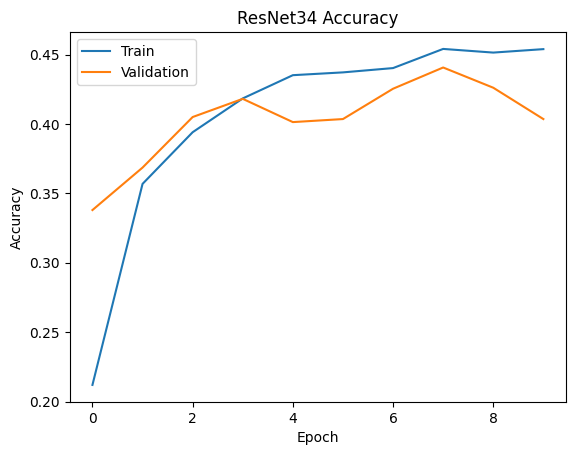

In [11]:
from matplotlib import pyplot as plt


train_acc = history_freeze_rn["train_acc"]
val_acc   = history_freeze_rn["val_acc"]

plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(["Train", "Validation"])
plt.title("ResNet34 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

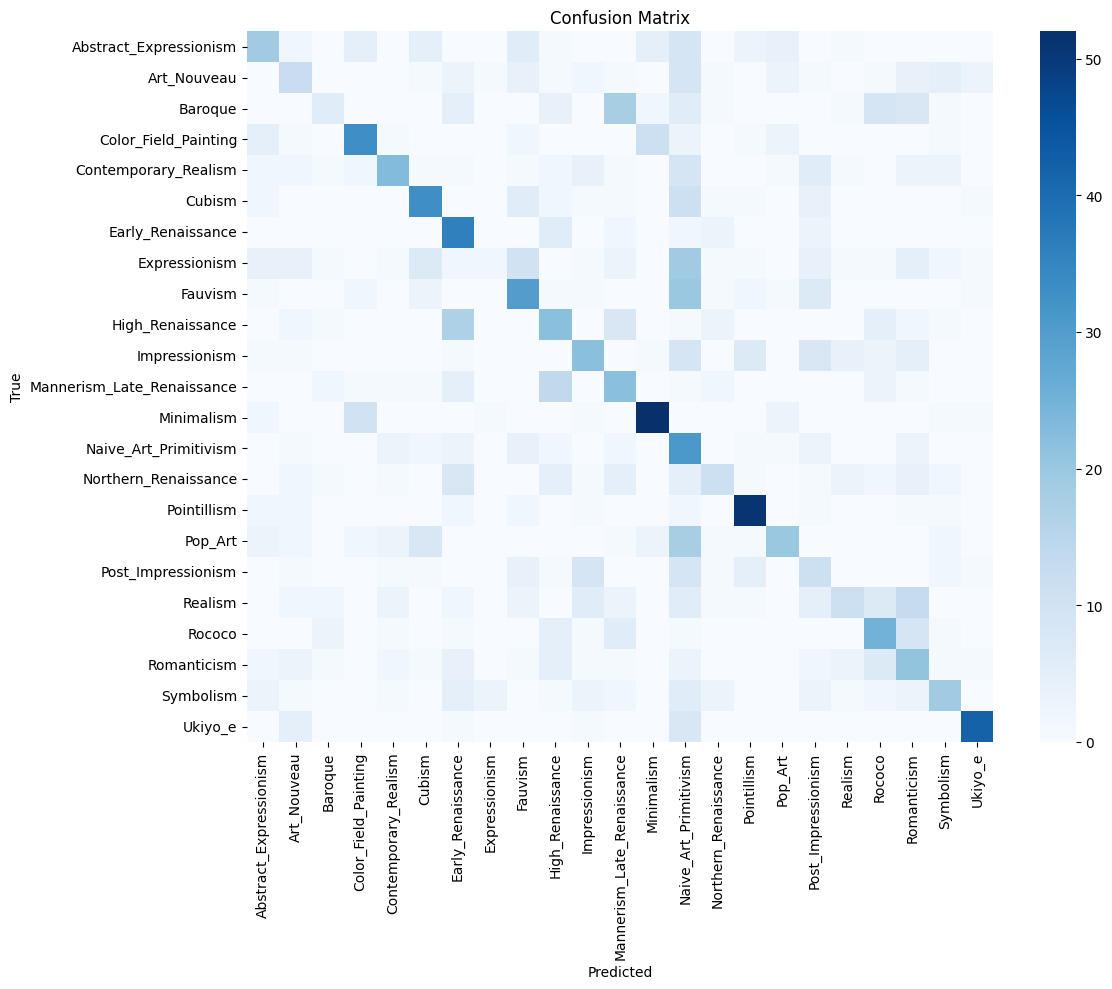

In [12]:
#Confusion matrix :

class_names = sorted(df_train["style_name"].unique())

cm = compute_confusion_matrix(
    model_rn,
    val_loader,
    device,
    class_names
)

plot_confusion_matrix(cm, class_names)


In [13]:

acc_per_style = accuracy_per_class(
    model_rn,
    val_loader,
    device,
    class_names
)

results = list(zip(class_names, acc_per_style))
results = sorted(results, key=lambda x: x[1], reverse=True)

for style, acc in results:
    print(f"{style}: {acc:.3f}")


Pointillism: 0.785
Ukiyo_e: 0.737
Minimalism: 0.732
Early_Renaissance: 0.692
Naive_Art_Primitivism: 0.554
Color_Field_Painting: 0.541
Cubism: 0.524
Rococo: 0.472
Fauvism: 0.429
Mannerism_Late_Renaissance: 0.415
Contemporary_Realism: 0.365
Romanticism: 0.356
High_Renaissance: 0.355
Impressionism: 0.355
Symbolism: 0.339
Abstract_Expressionism: 0.317
Pop_Art: 0.312
Post_Impressionism: 0.239
Art_Nouveau: 0.231
Northern_Renaissance: 0.212
Realism: 0.169
Baroque: 0.098
Expressionism: 0.029


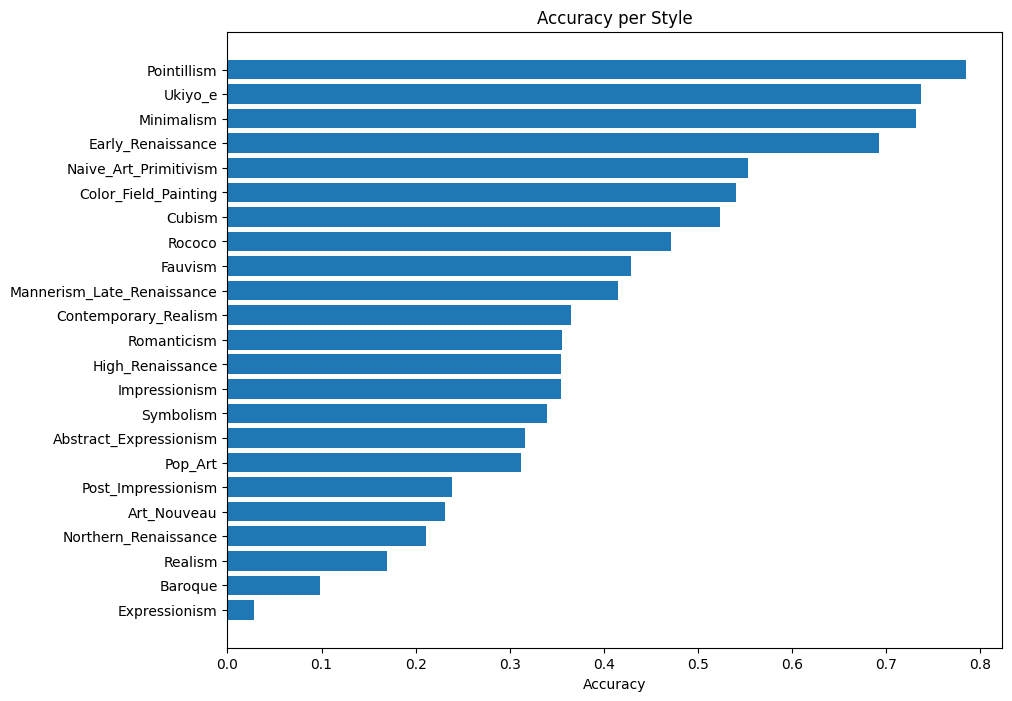

In [14]:
visualize_accuracy_per_style(results)

#### 1.6.2 Evaluation sur l'ensemble de test

In [15]:
best_model_weights = model_rn.state_dict()

test_acc, test_cm, report = evaluate_model(model_rn, test_loader, device)

print(f"Test Accuracy: {test_acc:.3f}")
print("Classification Report:")
print(report)

Test Accuracy: 0.403
Classification Report:
                            precision    recall  f1-score   support

    Abstract_Expressionism     0.4286    0.3061    0.3571        49
               Art_Nouveau     0.1475    0.1636    0.1552        55
                   Baroque     0.4783    0.1833    0.2651        60
      Color_Field_Painting     0.7674    0.6471    0.7021        51
      Contemporary_Realism     0.6429    0.4737    0.5455        57
                    Cubism     0.6000    0.5500    0.5739        60
         Early_Renaissance     0.3925    0.6000    0.4746        70
             Expressionism     0.0714    0.0172    0.0278        58
                   Fauvism     0.3690    0.5636    0.4460        55
          High_Renaissance     0.2619    0.3793    0.3099        58
             Impressionism     0.3860    0.3188    0.3492        69
Mannerism_Late_Renaissance     0.4189    0.4627    0.4397        67
                Minimalism     0.6667    0.8000    0.7273        55
   

Test Confusion Matrix:


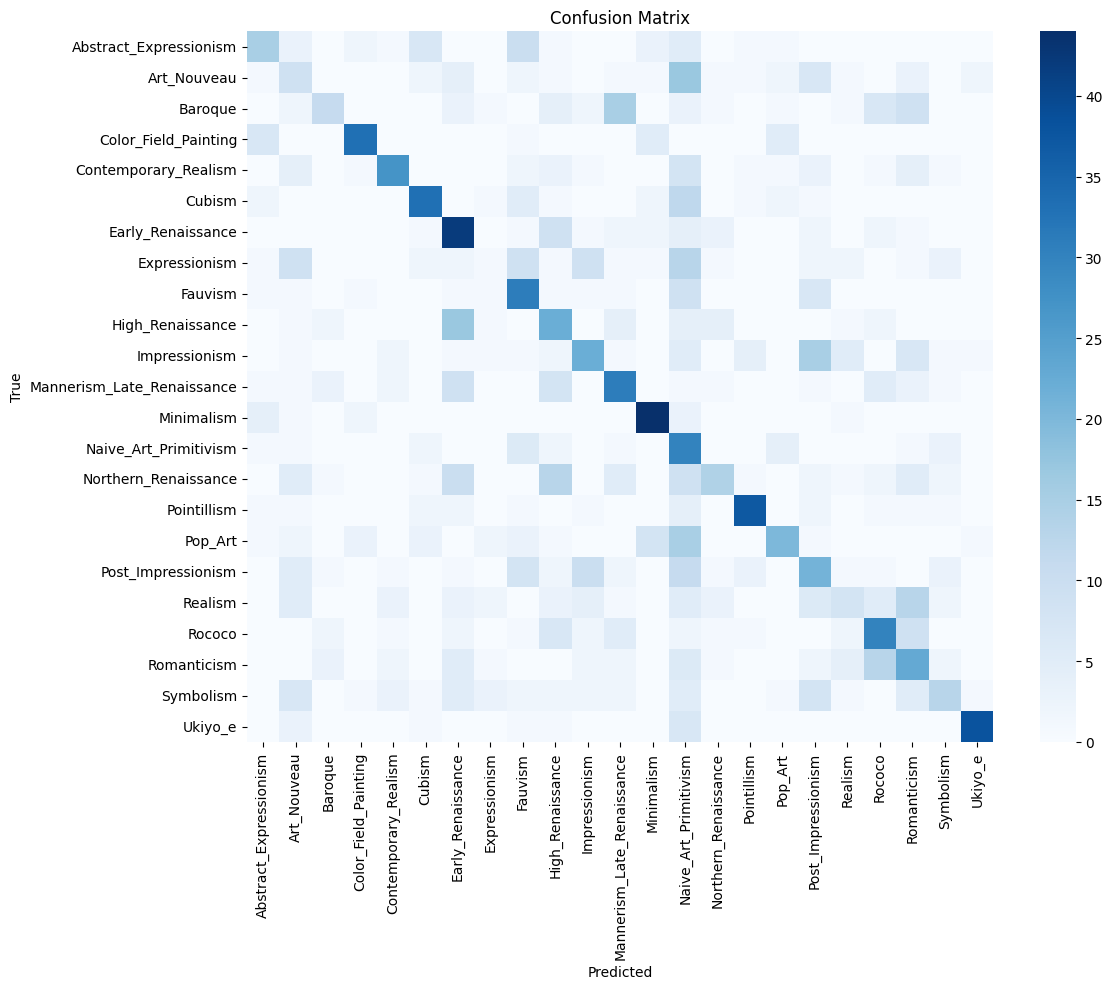

In [16]:
print("Test Confusion Matrix:")
plot_confusion_matrix(test_cm, class_names)